# MNIST, Decision Trees, and the Art of Generalization

## Learning Objectives
By the end of this notebook, you will understand:
- **Training vs. Testing Error**: The fundamental distinction that prevents overfitting
- **Generalization**: How well models perform on unseen data
- **Decision Trees on Image Data**: How to apply tree-based models to high-dimensional data

## The MNIST Dataset
MNIST (Modified National Institute of Standards and Technology) is the "Hello World" of computer vision:
- 70,000 handwritten digit images (0-9)
- Each image is 28×28 pixels (784 features)
- 60,000 training samples, 10,000 test samples

## Key Concepts We'll Explore
1. **Computer vision 101**: how are images stored
2. **Overfitting**: how to detect it


## Setting Up Our Environment

We'll need several libraries for this analysis:
- **torchvision**: For loading the MNIST dataset
- **sklearn**: For decision trees and ensemble methods
- **matplotlib**: For visualization
- **numpy**: For numerical operations
- **scipy**: For statistical functions (mode calculation)

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
from sklearn import tree
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import check_random_state
from torchvision import datasets, transforms


## Loading the MNIST Dataset

We'll use PyTorch's torchvision to download and load MNIST. This approach:
- Automatically downloads the dataset if not present
- Provides built-in data transformations
- Converts images to the format we need for machine learning
- We will be making extensive use of Pytorch in latter parts of the class

**Data Preprocessing Steps:**
1. Convert PIL images to PyTorch tensors
2. Normalize pixel values to [-1, 1] range
3. Convert to NumPy arrays for sklearn compatibility
4. Remove the channel dimension (MNIST is grayscale)

In [ ]:
import numpy as np
from torchvision import datasets, transforms

# Custom transform to convert tensor to numpy array and remove channel dimension
class ToNumpyNoChannel:
    def __call__(self, tensor):
        return tensor.squeeze(0).numpy()  # Remove channel dimension (C, H, W -> H, W)

# Define the transformation pipeline
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts PIL image to PyTorch tensor
    transforms.Normalize(mean=(0.5,), std=(0.5,)),  # Normalize to [-1, 1]
    ToNumpyNoChannel()  # Convert tensor to numpy array and remove channel dimension
])

# Load datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Access data and labels as NumPy arrays
X_train = np.array([train_dataset[i][0] for i in range(len(train_dataset))])  # Features
y_train = np.array([train_dataset[i][1] for i in range(len(train_dataset))])  # Labels
X_test = np.array([test_dataset[i][0] for i in range(len(test_dataset))])    # Features
y_test = np.array([test_dataset[i][1] for i in range(len(test_dataset))])    # Labels



100%|██████████| 9.91M/9.91M [00:00<00:00, 140MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 30.1MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 146MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.63MB/s]


## Data Shuffling:

Shuffling the data is crucial for several reasons:
- **Breaks any ordering bias**: Original data might be sorted by digit or other factors
- **Ensures representative splits**: When we split data later, we want each split to be representative
- **Improves training stability**: Random batches during training are more effective

**Important**: We use the same random seed to ensure reproducible results.

In [ ]:
"""
Now we do a random permutation of the data. This is often a good idea,
especially when we don't know how the data were created. For example, maybe
the digits were all given in order.
"""

t0 = time.time()
random_state = check_random_state(0)
permutation = random_state.permutation(X_train.shape[0])
X_train = X_train[permutation]
y_train = y_train[permutation]
permutation = random_state.permutation(X_test.shape[0])
X_test = X_test[permutation]
y_test = y_test[permutation]


## Exploratory Data Analysis (EDA)

Remember the cardinal rule: **Always look at your data first!**

Let's understand:
- **Dataset dimensions**: How many samples and features do we have?
- **Data structure**: How are images stored?
- **Class distribution**: Are all digits equally represented?
- **Data quality**: Any obvious issues we need to address?

In [ ]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")
y_train

Shape of X_train: (60000, 784)
Shape of y_train: (60000,)
Shape of X_test: (10000, 784)
Shape of y_test: (10000,)


array([8, 9, 8, ..., 3, 8, 8])

### Understanding Class Distribution

Let's examine how many examples we have for each digit (0-9). This is important because:
- **Balanced datasets** are easier to work with
- **Imbalanced datasets** may require special handling
- **Class distribution** affects our choice of evaluation metrics

**What we expect**: Roughly 6,000 examples per digit (60,000 total ÷ 10 digits)

In [ ]:
# How many times does each label appear in y_train and y_test

for i in range(10):
  c = str(i)
  ylist = y_train.tolist()
  num = ylist.count(c)
  print('The digit ', i, 'appears ', num, 'times')

The digit  0 appears  0 times
The digit  1 appears  0 times
The digit  2 appears  0 times
The digit  3 appears  0 times
The digit  4 appears  0 times
The digit  5 appears  0 times
The digit  6 appears  0 times
The digit  7 appears  0 times
The digit  8 appears  0 times
The digit  9 appears  0 times


### What happened?

See if you can understand what went wrong above.
We do it right in the code below.

In [ ]:
# Let's try again using some numpy commands

# occurrences of each digit in y_train
unique_digits, counts = np.unique(y_train, return_counts=True)

# results
for digit, count in zip(unique_digits, counts):
    print(f"Digit {digit}: {count} occurrences")

Digit 0: 5923 occurrences
Digit 1: 6742 occurrences
Digit 2: 5958 occurrences
Digit 3: 6131 occurrences
Digit 4: 5842 occurrences
Digit 5: 5421 occurrences
Digit 6: 5918 occurrences
Digit 7: 6265 occurrences
Digit 8: 5851 occurrences
Digit 9: 5949 occurrences


### Understanding Image Data Representation

Let's examine how a single image is stored:
- **Label**: The true digit (0-9)
- **Feature vector**: 784 pixel values (28×28 flattened)

**Key Observation**: Images are stored as arrays of pixel intensities, where each pixel value represents the darkness of that pixel.

In [ ]:
# Now let's have a look at some element of X and the corresponding element of y
print('The label is', y_train[0])
print('The feature vector is', X_train[0])

The label is 3
The feature vector is [[-1.         -1.         -1.         -1.         -1.         -1.
  -1.         -1.         -1.         -1.         -1.         -1.
  -1.         -1.         -1.         -1.         -1.         -1.
  -1.         -1.         -1.         -1.         -1.         -1.
  -1.         -1.         -1.         -1.        ]
 [-1.         -1.         -1.         -1.         -1.         -1.
  -1.         -1.         -1.         -1.         -1.         -1.
  -1.         -1.         -1.         -1.         -1.         -1.
  -1.         -1.         -1.         -1.         -1.         -1.
  -1.         -1.         -1.         -1.        ]
 [-1.         -1.         -1.         -1.         -1.         -1.
  -1.         -1.         -1.         -1.         -1.         -1.
  -1.         -1.         -1.         -1.         -1.         -1.
  -1.         -1.         -1.         -1.         -1.         -1.
  -1.         -1.         -1.         -1.        ]
 [-1.         -1. 

### Visualizing Handwritten Digits

Now we can see what the data actually looks like! This visualization helps us:
- **Verify data quality**: Are the images clear and readable?
- **Understand the task**: How much variation exists in handwriting?
- **Identify patterns**: What features might be useful for classification?
- **Debug issues**: If our model fails, we can examine specific examples

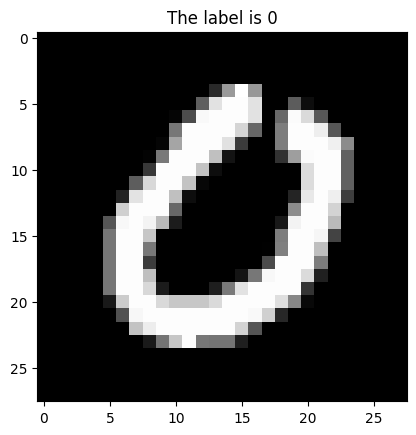

In [ ]:
# Since our data are handwritten digits, let's display the data
# so that we can see it.

# pick an element to display
index = 12
img = X_train[index]
label = y_train[index]
#img = img.reshape((28, 28))

# Plot it along with its label
plt.title('The label is {label}'.format(label=label))
plt.imshow(img, cmap='gray')
plt.show()

### Understanding Pixel Values

The numbers we see in the feature vector represent pixel intensities:
- **-1**: White pixels (background)
- **Values between -1 and 1**: Gray pixels (varying darkness)
- **1**: Black pixels (ink)

Understanding the data representation helps us choose appropriate preprocessing steps and interpret model decisions.

**A different representation**: pixel intensities can also be represented as integers between 0 and 255. We show this next.

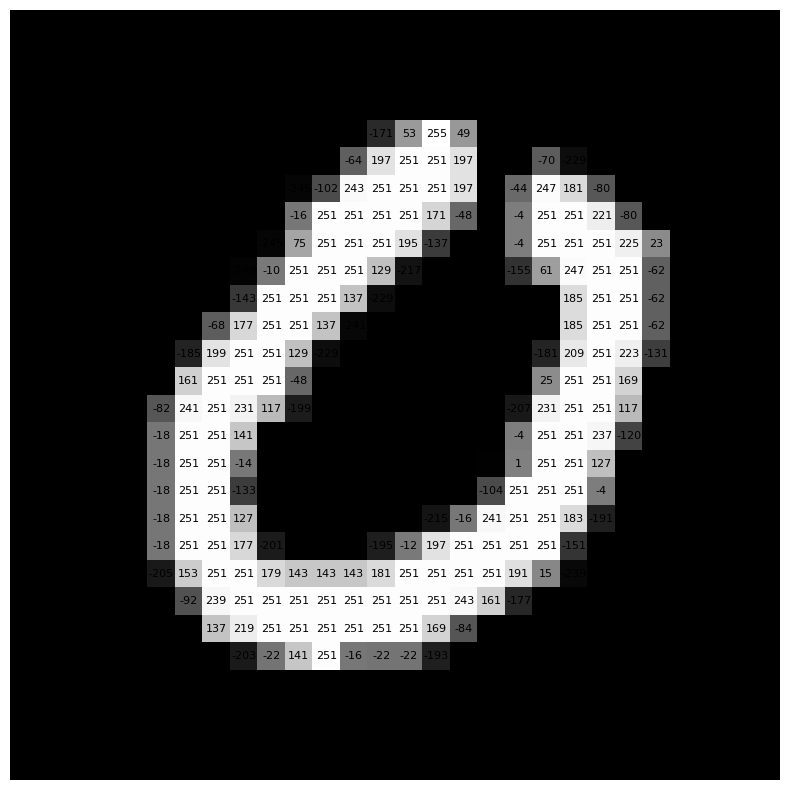

In [ ]:
image_np = (img.squeeze() * 255).astype(int)

# Plot the image with pixel intensities
plt.figure(figsize=(10, 10))
for i in range(image_np.shape[0]):
    for j in range(image_np.shape[1]):
        plt.text(j, i, str(image_np[i, j]), va='center', ha='center', fontsize=8, color="black")

plt.imshow(image_np, cmap="gray", interpolation="none")
plt.axis("off")
plt.show()


## Preparing Data for Decision Trees

Decision trees work with tabular data, so we need to transform our 2D images into 1D feature vectors:

**The transformation**:
- Original: `(60000, 28, 28)` → Reshaped: `(60000, 784)`
- Each image becomes a row with 784 features (one per pixel)

**Will this work?**: Decision trees can handle high-dimensional data. But let's think through what it means to use decision trees on images. Do we have a chance that it will work? What would a decision tree digit-classifier do?

In [ ]:
X_train = X_train.reshape((X_train.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))
X_train[0]

array([-1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.  

### Training A Decision Tree for MNIST

Let's start with a small subset of data to understand how decision trees work on image data, and also to make the computations faster. Remember that every time we run ``model.fit(X,y)`` we do many passes over the training data.

**Key parameters:**
- `max_depth=d`: Limits tree depth -- we already saw this in the previous notebook
- `criterion='gini'`: Uses Gini impurity for split decisions

In [ ]:
# There are 60,000 training data points. Let's just pick a few of them.
# We've already shuffled, so it's safe to just pick the first ones.
N_tr = 20
train_samples = N_tr
X_tr = X_train[:N_tr,:]
y_tr = y_train[:N_tr]
# check size
X_tr.shape

(20, 784)

Train score: 1.0000


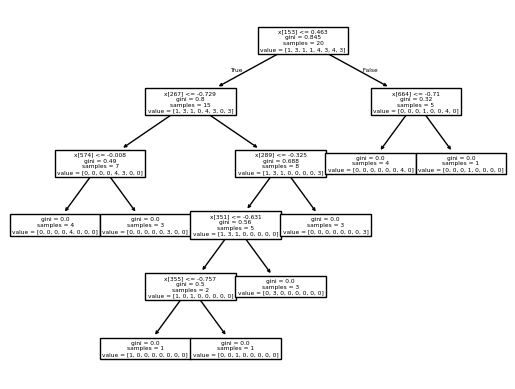

In [ ]:
# We now create a decision tree.
# The only parameter we pass is the max depth
decision_tree = tree.DecisionTreeClassifier(max_depth=5)

# Now we actually train it -- this is the computationally intensive step
decision_tree.fit(X_tr, y_tr)

# This is what it looks like
tree.plot_tree(decision_tree)

# And this is its accuracy on the training data
train_score = decision_tree.score(X_tr,y_tr)
print("Train score: %.4f" % train_score)

### Learning from Mistakes: Error Analysis

Visualizing prediction errors is one of the most valuable debugging tools in machine learning:

**What to look for:**
- **Systematic errors**: Does the model consistently confuse certain digits?
- **Edge cases**: What types of handwriting cause problems?
- **Data quality issues**: Are some images too blurry or unusual?

**Always a good idea**: Understanding where your model fails helps you improve it.

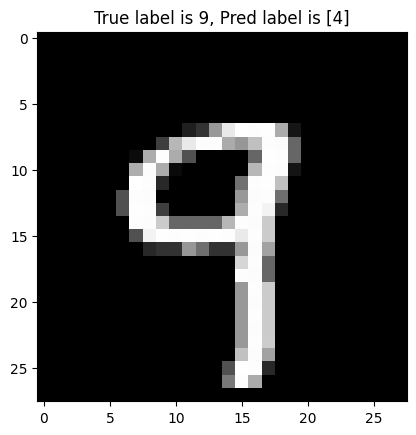

array([4])

In [ ]:
# pick an element to display from the test images
index = 13
img = X_test[index]
y_true = y_test[index]
img = img.reshape((28, 28))

# get the predicted label
y_hat = decision_tree.predict(X_test[index].reshape(1,-1))

# Plot it along with its label
plt.title('True label is {label_t}, Pred label is {label_p}'.format(label_t=y_true,label_p = y_hat))
plt.imshow(img, cmap='gray')
plt.show()
y_hat

## The Core Concept: Training vs. Testing Accuracy (Error)

We'll train decision trees of varying complexity and observe how training accuracy (error) and testing accuracy (error) behave.

**What we expect to see:**
- **Training accuracy**: Increases as tree depth increases (model fits training data better)
- **Testing accuracy**: Initially increases, then decreases (overfitting occurs)

**The sweet spot**: Ideally we will find a place where testing accuracy (error) is minimized, (accuracy is high) before overfitting begins. But not all models can accomplish this. We will see how well we can do with trees. We will do the same thing with other models later.

**It should not surprise us that**: A model can perform perfectly on training data and nevertheless fail on new data.

In [ ]:
# Again a train-test split
#train_samples = 50000
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, train_size=train_samples, test_size=70000-train_samples, random_state=0)
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

training_scores = []
testing_scores = []
depth_values = range(15)
for depth in depth_values:
    dt = tree.DecisionTreeClassifier(max_depth=depth+1, criterion='gini')
    dt.fit(X_train,y_train)
    train_score = dt.score(X_train,y_train)
    test_score = dt.score(X_test, y_test)
    training_scores.append(train_score)
    testing_scores.append(test_score)

print('These are the training scores:',training_scores)
print('These are the testing scores:',testing_scores)

These are the training scores: [0.1982, 0.34181666666666666, 0.49151666666666666, 0.5898833333333333, 0.6722666666666667, 0.73825, 0.7866, 0.8262666666666667, 0.8665166666666667, 0.8995166666666666, 0.9276166666666666, 0.9491166666666667, 0.9648666666666667, 0.9769666666666666, 0.9843666666666666]
These are the testing scores: [0.1994, 0.3447, 0.4953, 0.5957, 0.6747, 0.7416, 0.7853, 0.8186, 0.8502, 0.866, 0.875, 0.8777, 0.8806, 0.8829, 0.8828]


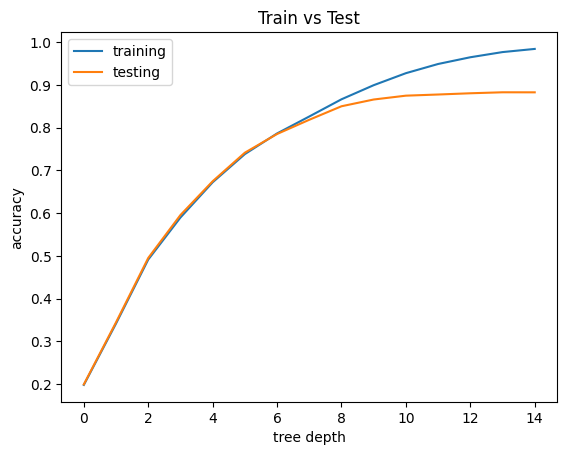

In [ ]:
# Easier to see them on a graph, vs depth of tree
import matplotlib.pyplot as plt
fig, ax = plt.subplots()  # Create a figure containing a single axes.
ax.plot(training_scores,label='training')
ax.plot(testing_scores,label='testing')
ax.set_xlabel('tree depth')  # Add an x-label to the axes.
ax.set_ylabel('accuracy')  # Add a y-label to the axes.
ax.set_title("Train vs Test")  # Add a title to the axes.
ax.legend();  # Add a legend.

## Comments / Thoughts?

## Optional (Looking ahead)

We will describe random forests later. If you feel like figuring out the syntax on your own (read the documentation in sklearn -- better than having gemini/gpt just produce the code for you), then:

* Use random forests, fixing the number of trees in the average, and plotting training and testing accuracy for increasing tree depth.